In [1]:
from pylab import *
from input_environment_defs import *

Splikes version  0.1.5
Plasticnet version  0.1.17


In [2]:
def get_input_patch_examples(Lnorm_fname,Rnorm_fname,scale=-1,rf_size=19,
                             noise=[0.1,0.1],contrast=[1,1]):
    
    eta=2e-6

    

    number_of_neurons=1,        

    pre1=pn.neurons.natural_images(Lnorm_fname,
                                   rf_size=rf_size,verbose=False)

    if scale is None:
        pre2=pn.neurons.natural_images(Rnorm_fname,rf_size=rf_size,
                                other_channel=pre1,
                                verbose=False)
    else:
        pre2=pn.neurons.natural_images(Rnorm_fname,rf_size=int(rf_size),
                                other_channel=pre1,scale=scale,
                                verbose=False)

    
    sigma=noise[0]
    if contrast[0]!=1:
        pre1+=pn.neurons.process.scale_shift(contrast,0)
    pre1+=pn.neurons.process.add_noise_normal(0,sigma)

    sigma=noise[1]
    if contrast[1]!=1:
        pre2+=pn.neurons.process.scale_shift(contrast,0)
    pre2+=pn.neurons.process.add_noise_normal(0,sigma)
    
    pre=pre1+pre2

    sim=pn.simulation(100)
    sim.monitor(pre,['output'],1)
    sim.monitor(pre1,['pattern','p','c','r'],1)
    sim.monitor(pre2,['pattern','p','c','r'],1)

    pn.run_sim(sim,[pre],[],display_hash=False,print_time=False)

    m=sim.monitors['output']
    t,X=m.arrays()
    
    X=X[1:,:]
    
    
    return sim,X


In [3]:
base_image_file=asdf_fname='asdf/bbsk081604_all_scale2.asdf'

Using cache_images/cache_images_ba63c51e208a95ef81b4eebcc3767cfd.asdf from cache.

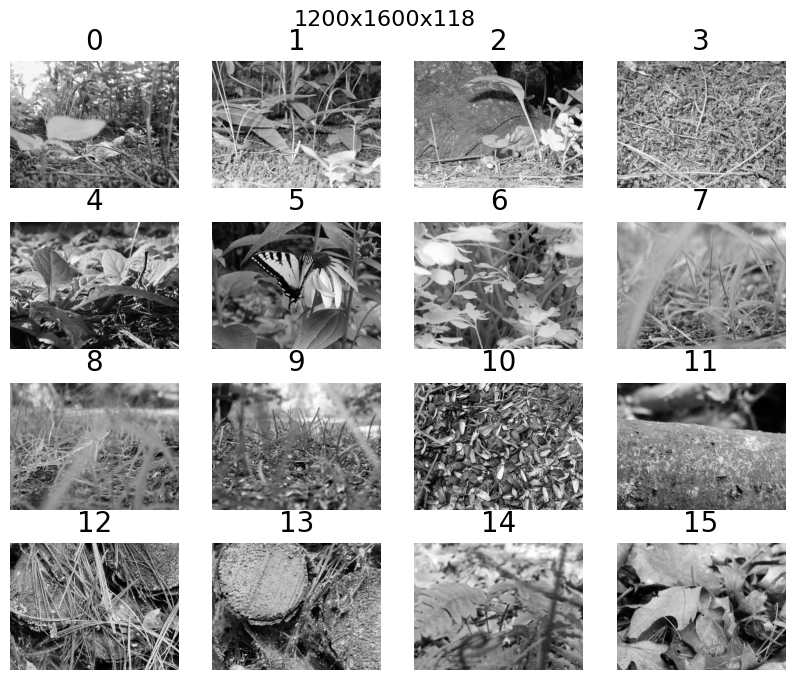

In [4]:
Lnorm_fname=pi5.filtered_images(base_image_file,
                                {'type':'zoom','scale':2},
                            {'type':'norm'},
                            verbose=True)


pi5.view(Lnorm_fname,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15])

In [5]:
Lnorm_fname=pi5.filtered_images(base_image_file,
                            {'type':'norm'},
                            verbose=True)
Rnorm_fname=pi5.filtered_images(base_image_file,
                                {'type':'zoom','scale':1.5},
                            {'type':'norm'},
                            verbose=True)


Using cache_images/cache_images_66a66c3735b3f9a2f3b3b0c5cf4fc5c0.asdf from cache.Using cache_images/cache_images_6b855786aea0b1da5ba8b47aefdce967.asdf from cache.

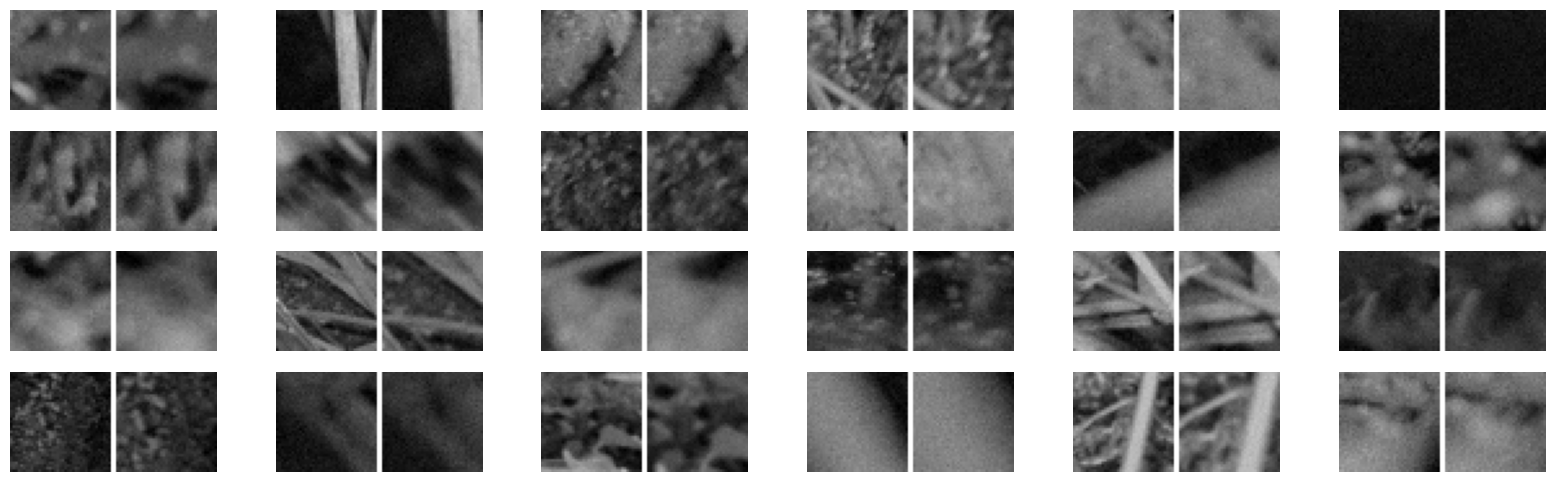

In [6]:
rf_size=39
sim,X=get_input_patch_examples(Lnorm_fname,Rnorm_fname,rf_size=rf_size,scale=1.5)
ims=inputs_to_images(X,buffer=2)
figure(figsize=(20,6))
for i in range(24):
    im=ims[i]
    subplot(4,6,i+1)
    imshow(im,cmap=plt.cm.gray)
    axis('off')


In [7]:
X.shape

(101, 3042)

In [8]:
def get_input_patch_examples_with_jitter(Lnorm_fname,Rnorm_fname,scale=-1,rf_size=19,
                             noise=[0.1,0.1],contrast=[1,1],
                                         mu_c=10,sigma_c=2,    
                                           mu_r=0,sigma_r=1
                                        ):
    
    eta=2e-6

    

    number_of_neurons=1,

    pre1=pn.neurons.natural_images_with_jitter(Lnorm_fname,
                                   rf_size=rf_size,
                                    sigma_r=1,
                                   sigma_c=1,
                                   verbose=False)

    pre2=pn.neurons.natural_images_with_jitter(Rnorm_fname,rf_size=rf_size,
                                other_channel=pre1,
                               mu_r=mu_r,mu_c=mu_c,
                               sigma_r=1,sigma_c=sigma_c,
                                               scale=scale,
                                verbose=False)

    sigma=noise[0]
    if contrast[0]!=1:
        pre1+=pn.neurons.process.scale_shift(contrast,0)
    pre1+=pn.neurons.process.add_noise_normal(0,sigma)

    sigma=noise[1]
    if contrast[1]!=1:
        pre2+=pn.neurons.process.scale_shift(contrast,0)
    pre2+=pn.neurons.process.add_noise_normal(0,sigma)

    pre=pre1+pre2

    sim=pn.simulation(99)
    sim.monitor(pre,['output'],1)
    sim.monitor(pre1,['pattern','p','c','r','pa','ca','ra'],1)
    sim.monitor(pre2,['pattern','p','c','r','pa','ca','ra'],1)

    pn.run_sim(sim,[pre],[],display_hash=False,print_time=False)

    m=sim.monitors['output']
    
    t,X=m.arrays()
    
    
    X=X[1:,:]

    
    
    return sim,X


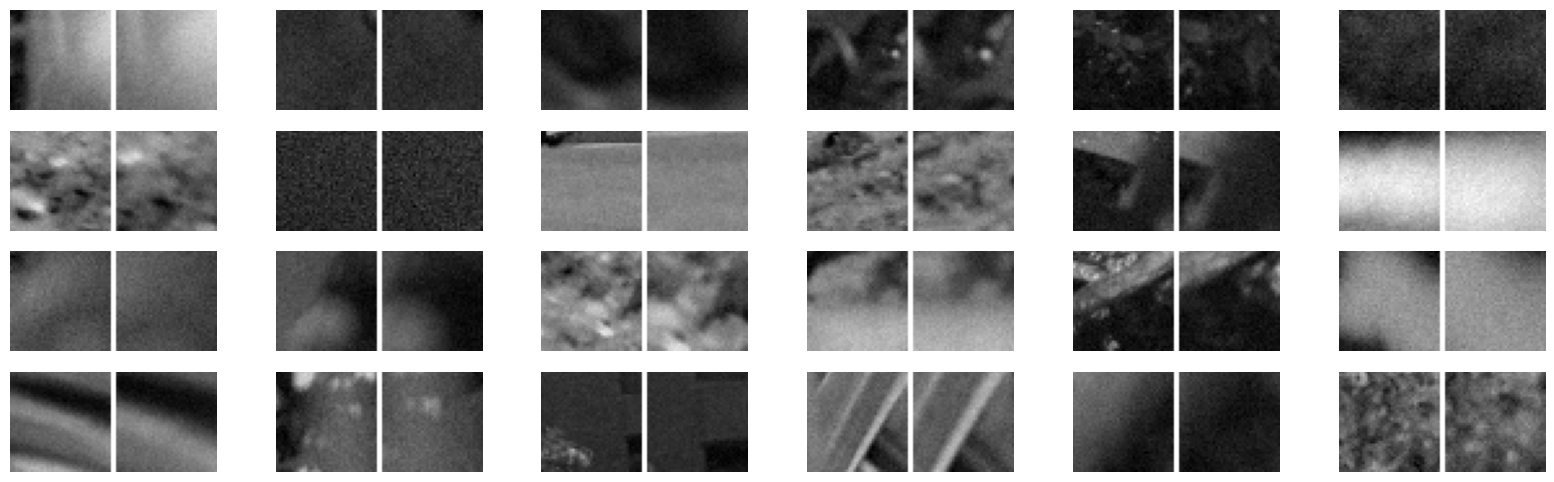

In [9]:
rf_size=39
sim,X=get_input_patch_examples_with_jitter(Lnorm_fname,Rnorm_fname,
                                           rf_size=rf_size,scale=1.5)
ims=inputs_to_images(X,buffer=2)
figure(figsize=(20,6))
for i in range(24):
    im=ims[i]
    subplot(4,6,i+1)
    imshow(im,cmap=plt.cm.gray)
    axis('off')
